## Evaluation using MSEP

Experiments

[Explain the experiments, varying N consistency, varying bz etc.]

Code Overview

[Explain functions]

---

#### Imports

In [1]:
import os
import re
import torch

import pandas as pd

from torch.nn import MSELoss
from torch.utils.data import DataLoader

from cocodeel.dataset import CovarDataset
from cocodeel.model import BaseNetwork, CovarNetwork
from cocodeel.posthoc_model import PostHocCovarNetwork
from cocodeel.benchmarking.posthoc_model import PostHocOrthNetwork

from experiments.simulation_images.backbone import TrafficBackbone
from experiments.simulation_images.utils import simulate_traffic_light_data, predict, mspe_decomposition, simulate_dataloader

print(f"torch.__version__: {torch.__version__}")
print(f"torch.version.cuda: {torch.version.cuda}")
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

torch.__version__: 2.9.0+cu130
torch.version.cuda: 13.0
Using device: cuda:0


#### Default Parameters

In [2]:
simulation_params = {
    'n': 3200, 'bz': 1., 'b2': 1., 'b3': 1.,
    'cv1': 0.8, 'cv2': 0.5, 'sdy': 1.
}
trainer_params = {
    'device': DEVICE, 'loss_fn': MSELoss(), 'epochs': 1000, 'lr': 1e-3, 'weight_decay': 1e-4, 'patience': 12
}
model_params = {
    'backbone': TrafficBackbone,
    'backbone_params': {"out_features": 32},
    'num_covariates': 1
}
posthoc_configs = {
    "posthoc": dict(cls=PostHocCovarNetwork),
    "posthoc_lam0": dict(cls=PostHocCovarNetwork, fit_kwargs={"lam": 0.0}),
    "posthoc_orth": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}),
    "posthoc_orth_lam0": dict(cls=PostHocCovarNetwork, init_kwargs={"orthogonalize": True}, fit_kwargs={"lam": 0.0}),
    "posthoc_web": dict(cls=PostHocOrthNetwork)
}

### Evaluation of Results

#### Functions for evaluation

In [3]:
def load_base_model(model_path, model_cls, model_params):
    """Load a torch model from file."""
    model = model_cls(
        backbone=model_params['backbone'],
        backbone_params=model_params['backbone_params'],
        num_covariates=model_params['num_covariates']
    )
    state_dict = torch.load(model_path, map_location="cpu")
    # Check if state dict has "is_centered". If not: Add it.
    if 'is_centered' not in state_dict:
        state_dict['is_centered'] = torch.tensor(True)
    model.load_state_dict(state_dict)
    model.eval()
    return model

def load_posthoc_model(model_path, model_cls, model_params, init_kwargs={}):
    """Load a post-hoc model from file."""
    base_model = BaseNetwork(
        backbone=model_params['backbone'],
        backbone_params=model_params['backbone_params'],
        num_covariates=model_params['num_covariates']
    )
    model = model_cls(
        model=base_model,
        num_covariates=model_params['num_covariates'],
        **init_kwargs
    )
    state_dict = torch.load(model_path, map_location="cpu")
    # Check if state dict has "is_centered". If not: Add it.
    if 'is_centered' not in state_dict:
        state_dict['is_centered'] = torch.tensor(True)
    model.load_state_dict(state_dict)
    model.eval()
    return model

In [ ]:
@torch.no_grad()
def evaluate_experiment(
    exp_dir,
    simulation_params,
    model_params,
    posthoc_configs,
    test_seed=1234,
    test_n=800,
):

    # --- Parse parameters from folder name ---
    pattern = r"n=(\d+)_bz=([\d.]+)_cv1=([\d.]+)_p=(\d+)_q=(\d+)"
    n, bz, cv1, p, q = map(float, re.search(pattern, exp_dir).groups())

    # --- Update parameters manually ---
    sim_params = simulation_params.copy()
    sim_params.update({"n": int(n), "bz": bz, "cv1": cv1})
    model_params = model_params.copy()
    model_params["num_covariates"] = int(p)
    model_params["backbone_params"]["out_features"] = int(q)

    # --- Create test data ---
    test_params = sim_params.copy()
    test_params["n"] = test_n
    X, Z, y, fx, fz, fr = simulate_traffic_light_data(**test_params, seed=test_seed)
    test_loader = DataLoader(CovarDataset(X, Z, y), batch_size=test_n // 30, shuffle=False)

    results = []
    model_files = sorted(f for f in os.listdir(exp_dir) if f.endswith(".pth"))

    # --- Evaluate model ---
    for model_name in ['base', 'covar'] + list(posthoc_configs.keys()):
        # --- Load models and predict ---
        files = [
            f for f in model_files
            if re.fullmatch(rf"{re.escape(model_name)}_\d+\.pth", f)
        ]
        if not files:
            print(f"No model files found for model {model_name}, skipping.")
            continue
        print(f"Loading {len(files)} models for {model_name}...")
        y_preds, fx_preds, fz_preds = [], [], []
        for run_id, f in enumerate(files):
            model_path = os.path.join(exp_dir, f)
            if model_name == "base":
                model = load_base_model(model_path, BaseNetwork, model_params)
            elif model_name == "covar":
                model = load_base_model(model_path, CovarNetwork, model_params)
            else:
                model = load_posthoc_model(
                    model_path, 
                    posthoc_configs[model_name]["cls"],
                    model_params, 
                    init_kwargs=posthoc_configs[model_name].get("init_kwargs", {})
                )
            y_pred, fx_pred, fz_pred = predict(model, test_loader)
            y_preds.append(y_pred)
            fx_preds.append(fx_pred)
            fz_preds.append(fz_pred)
        y_preds = torch.stack(y_preds, dim=1).squeeze()
        fx_preds = torch.stack(fx_preds, dim=1).squeeze()
        fz_preds = torch.stack(fz_preds, dim=1).squeeze()
        # --- Evaluate predictions ---
        metrics = {
            "y": mspe_decomposition(y_preds, y),
            "fx": mspe_decomposition(fx_preds, fx),
            "fz": mspe_decomposition(fz_preds, fz),
            "fr": mspe_decomposition(fx_preds, fr)
        }
        # --- Flatten into rows ---
        for effect, comps in metrics.items():
            for metric_name, value in comps.items():
                results.append({
                    "n": int(n),
                    "bz": bz,
                    "cv1": cv1,
                    "p": int(p),
                    "q": int(q),
                    "model": model_name,
                    "effect": effect,
                    "metric": metric_name,
                    "value": value,
                })

    return pd.DataFrame(results)

In [ ]:
# Process all experiments in a directory and combine results
def process_experiment_directory(base_dir, simulation_params, model_params, posthoc_configs):
    """Process all experiment subfolders and combine results into one DataFrame."""
    
    # Step A: Find all subfolders
    subfolders = [f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
    
    # Step B: Call evaluate_experiment for each subfolder
    all_results = []
    for subfolder in sorted(subfolders):
        exp_path = os.path.join(base_dir, subfolder)
        df_exp = evaluate_experiment(exp_path, simulation_params, model_params, posthoc_configs)
        df_exp['experiment_folder'] = subfolder
        all_results.append(df_exp)
    
    # Step C: Combine dataframes
    return pd.concat(all_results, ignore_index=True)

### Load and Evaluate Experiment

In [81]:
# Example usage - process the increasing_N directory
base_directory = "outputs/simulation_images/increasing_q"
df_all = process_experiment_directory(
    base_directory, 
    simulation_params, 
    model_params, 
    posthoc_configs
)

# Save combined results (including datetime to avoid overwriting)
output_path = os.path.join(base_directory, f"combined_results_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv")
df_all.to_csv(output_path, index=False)
print(f"Saved combined results to: {output_path}")

# Show summary
print(f"Total experiments: {df_all['experiment_folder'].nunique()}")
print(f"Sample sizes (n): {sorted(df_all['n'].unique())}")
print(f"Models: {df_all['model'].unique().tolist()}")
print(f"Effects: {df_all['effect'].unique().tolist()}")

Loading 100 models for base...
No model files found for model covar, skipping.
Loading 100 models for posthoc...
No model files found for model covar, skipping.
Loading 100 models for posthoc...
Loading 100 models for posthoc_lam0...
Loading 100 models for posthoc_lam0...
Loading 100 models for posthoc_orth...
Loading 100 models for posthoc_orth...
Loading 100 models for posthoc_orth_lam0...
Loading 100 models for posthoc_orth_lam0...
Loading 100 models for posthoc_web...
Loading 100 models for posthoc_web...
Loading 100 models for base...
Loading 100 models for base...
No model files found for model covar, skipping.
Loading 100 models for posthoc...
No model files found for model covar, skipping.
Loading 100 models for posthoc...
Loading 100 models for posthoc_lam0...
Loading 100 models for posthoc_lam0...
Loading 100 models for posthoc_orth...
Loading 100 models for posthoc_orth...
Loading 100 models for posthoc_orth_lam0...
Loading 100 models for posthoc_orth_lam0...
Loading 100 mod

---

## Plotting

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_experiment_results(df, x='n', effects=['y', 'fx'], metrics=['mspe'], models=None):
    """Create a nice visualization of experiment results using seaborn."""
    
    # Filter data
    if models is None:
        models = ['base', 'covar', 'posthoc', 'posthoc_lam0', 'posthoc_orth', 'posthoc_orth_lam0', 'posthoc_web']
    
    df_plot = df[
        (df["effect"].isin(effects)) &
        (df["metric"].isin(metrics)) &
        (df["model"].isin(models))
    ]
    
    # Define custom palette based on viridis colors
    # Group by base, posthoc, orthogonalized and other (web).
    base_pal = sns.color_palette("viridis", n_colors=16)
    palette = {
        "base": base_pal[15],
        "covar": base_pal[14], 
        "posthoc": base_pal[8],
        "posthoc_lam0": base_pal[8],
        "posthoc_orth": base_pal[4],
        "posthoc_orth_lam0": base_pal[4],
        "posthoc_web": base_pal[13]
    }
    
    sns.set_style("whitegrid")
    
    # Create FacetGrid
    g = sns.FacetGrid(
        df_plot,
        col="metric" if len(metrics) > 1 else None,
        row="effect" if len(effects) > 1 else None,
        hue="model",
        sharey=False,
        height=4,
        aspect=2.0,
        palette=palette
    )
    
    # Ensure lam0 models have different line styles
    def plot_line(data, color=None, label=None, **kwargs):
        line_style = '-' if 'lam0' not in label else '--'
        sns.lineplot(
            data=data, x=x, y="value",
            marker="o", color=color, label=label, linestyle=line_style, **kwargs
        )
    
    g.map_dataframe(plot_line)
    g.add_legend(title="Model")
    
    # Customize legend
    g._legend.set_bbox_to_anchor((1.05, 0.85))
    g._legend.get_frame().set_edgecolor('black')
    g._legend.get_frame().set_facecolor('white')
    g._legend.get_frame().set_linewidth(1.5)
    
    # Format axes
    for ax in g.axes.flat:
        if x == 'n':
            ax.set_xscale("log")
        else:
            ax.set_xscale("linear")
        ax.set_xlabel("Number of observations (log scale)", fontsize=12)
        ax.set_ylabel("MSPE", fontsize=12)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        # if effect is 'y' set yaxis to 0.99 - 1.10, if it is any other effect set to -0.01 - 0.25
        effect = ax.get_title().split(' = ')[-1] if 'effect' in ax.get_title() else None
        if effect == 'y':
            ax.set_ylim(0.99, 1.10)
        elif effect in ['fx', 'fz', 'fr']:
            ax.set_ylim(-0.01, 0.25)

    # Set titles based on effects
    if len(effects) > 1:
        for i, effect in enumerate(effects):
            if effect == 'y':
                g.axes[i,0].set_title(r'MSPE$(\hat{y})$', fontsize=16)
            elif effect == 'fx':
                g.axes[i,0].set_title(r'MSPE$(\hat{f}_X)$', fontsize=16)
            elif effect == 'fz':
                g.axes[i,0].set_title(r'MSPE$(\hat{f}_Z)$', fontsize=16)
            elif effect == 'fr':
                g.axes[i,0].set_title(r'MSPE$(\hat{f}^\mathrm{re}_X)$', fontsize=16)
    
    plt.tight_layout()
    return g


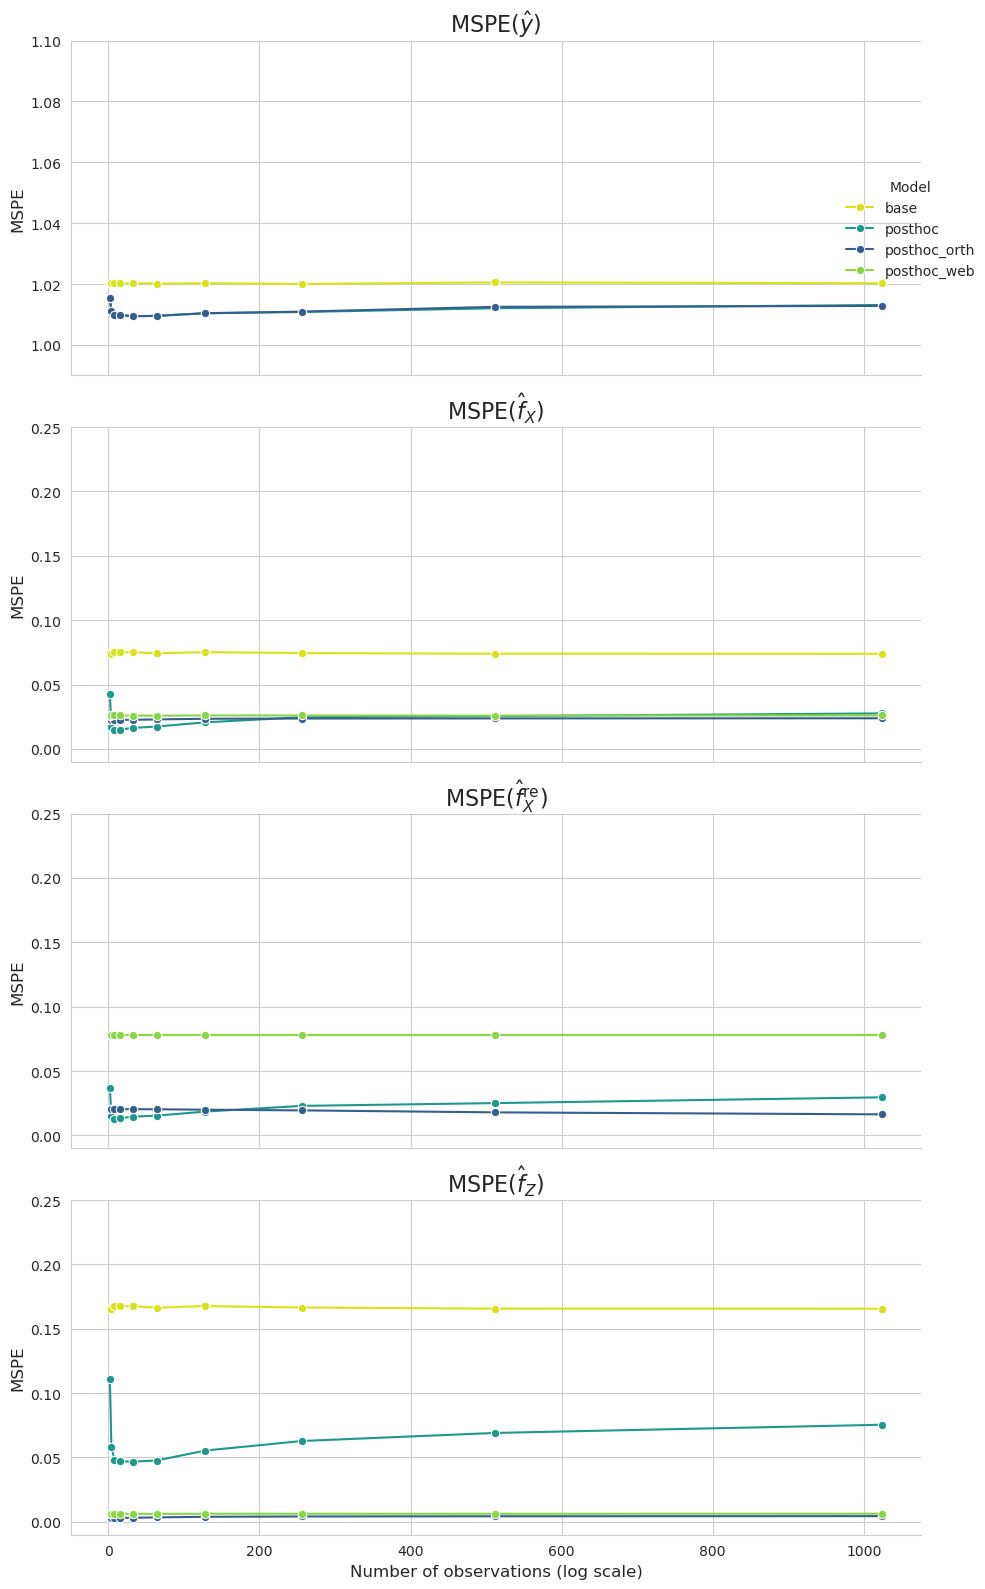

In [85]:
df_all = pd.read_csv("results/simulation_images/increasing_q_20251023_113829.csv")
# Example usage after df_all is created:
plot_experiment_results(df_all, x='q', effects=['y', 'fx', 'fr', 'fz'], metrics=['mspe'], models=['base', 'posthoc', 'posthoc_orth', 'posthoc_web'])
plt.show()

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to only mse/bias for y and fx
df_plot = df[
    (df["Metric"].isin(["bias_squ"])) &
    (df["Effect"].isin(["y", "fx"])) &
    (df["Model"].isin([ "covar", "base", "posthoc",]))
]

# Build FacetGrid: rows = Effect, cols = Metric
# define palette so that posthoc and post-hoc (no penalty) have similar (but not identical) colors.
# Define custom palette based on viridis colors!
base_pal = sns.color_palette("viridis", n_colors=8)
base_col = base_pal[7]
covar_col = base_pal[6]
posthoc_col = base_pal[3]
posthoc_no_pen_col = base_pal[2]

palette = {
    "base": base_col,
    "covar": covar_col,
    "posthoc": posthoc_col,
}

sns.set_style("whitegrid")

g = sns.FacetGrid(
    df_plot,
    col="Metric",
    row="Effect",
    hue="Model",              # FacetGrid handles model grouping
    sharey=False,
    height=4,
    aspect=2,
    palette=palette
)

# Lineplot with error bands; color comes from FacetGrid
def plot_line(data, color=None, label=None, **kwargs):
    sns.lineplot(
        data=data, x="N", y="mean",
        marker="o", color=color, label=label, **kwargs
    )
    plt.fill_between(
        data["N"],
        data["mean"] - data["std"],
        data["mean"] + data["std"],
        alpha=0.2, color=color
    )


# Map plotting function and keep legend
g.map_dataframe(plot_line)
g.add_legend(title="Model")   # legend now shows base vs posthoc
# Move legend to upper right corner of first subplot
g._legend.set_bbox_to_anchor((0.95, 0.85))
# Have box around legend with background white
g._legend.get_frame().set_edgecolor('black')
g._legend.get_frame().set_facecolor('white')
# Increase legend border width
g._legend.get_frame().set_linewidth(1.5)
# Set legend title to "Model"
g._legend.set_title("Model")
# Increase legend font size
for text in g._legend.texts:
    text.set_fontsize(12)
# Increase legend title font size
g._legend.get_title().set_fontsize(14)

# Log scale for N. Add ticks at every N.
# Name x-axis as "Number of Observations (log scale)". Name y-axis as (latex formatted): "\bar MSE pm SD"-.
for ax in g.axes.flat:
    ax.set_xscale("log")
    ax.set_xlabel("Number of observations (log scale)", fontsize=12)
    ax.set_ylabel(r'$\mu(\mathrm{MSE}) \pm \mathrm{sd}(\mathrm{MSE})$', fontsize=12)
    ax.set_xticks([200, 400, 800, 1600, 3200, 6400, 12800, 25600])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# For the first ax, set ylim as [1. 1.10]. Draw a horizontal "sigma^2]" line at y=1.00
#g.axes[0,0].set_ylim(0.99, 1.10)
#g.axes[0,0].axhline(1.0, color='red', linestyle='--')
## Label (noise floor)
#g.axes[0,0].text(225, 1.002, r'$\sigma^2$', color='red', fontsize=12)
## For the second ax, set ylim as [0, 0.25]. Draw a horizontal line at y=0.00.
#g.axes[1,0].set_ylim(-0.01, 0.25)
#g.axes[1,0].axhline(0.0, color='red', linestyle='--', label='0.0')

# Make the titles really bold. For first axis it should be "MSE(yhat)" and for second axis "MSE(fxhat)".
# Use LaTeX formatting and fonts.
g.axes[0,0].set_title(r'MSE$(\hat{y})$', fontsize=16)
g.axes[1,0].set_title(r'MSE$(\hat{f}_X)$', fontsize=16)

plt.tight_layout()
plt.show()


KeyError: 'Metric'

## Laboratory (discard this)

In [ ]:
# Manual testing.

# Data for training.
# Simulate data.
X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=400, seed=1)
N = X.shape[0]
# Create training and validation.
train_data = CovarDataset(X[:N // 2], Z[:N // 2], y[:N // 2])
val_data = CovarDataset(X[N // 2:], Z[N // 2:], y[N // 2:])
# Create dataloaders.
train_loader = DataLoader(train_data, batch_size= N // 30, shuffle=True)
val_loader = DataLoader(val_data, batch_size= N // 30, shuffle=False)

# Load base model.
model = BaseNetwork(backbone=experiments.traffic_light.backbone.TrafficBackbone, backbone_params={"out_features": 32})
model.load_state_dict(torch.load(
    f"../../outputs/traffic_light/consistency_bz=1.0_corrv1=0.8/traffic_light_nobs=400_nruns=100_20251001-174205/base_1.pth"))
model.eval()

# Load posthoc model.
posthoc_model = PostHocCovarNetwork(model, num_covariates=Z.shape[1])
posthoc_model.load_state_dict(torch.load(
    f"../../outputs/traffic_light/consistency_bz=1.0_corrv1=0.8/traffic_light_nobs=400_nruns=100_20251001-174205/posthoc_1.pth"))
posthoc_model.eval()

PostHocLinearCovarNetwork(
  (backbone): TrafficBackbone(
    (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (pool): AdaptiveAvgPool2d(output_size=(4, 4))
    (fc): Linear(in_features=512, out_features=32, bias=True)
  )
  (center_x): Center()
  (fx): Linear(in_features=32, out_features=1, bias=False)
  (fz): Linear(in_features=1, out_features=1, bias=False)
  (center_z): Center()
)

In [ ]:
device = 'cpu'
features = []
covariates = []
targets = []

# Data for training.
# Simulate data.
X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=400, seed=1)
N = X.shape[0]
# Create training and validation.
train_data = CovarDataset(X[:N // 2], Z[:N // 2], y[:N // 2])
val_data = CovarDataset(X[N // 2:], Z[N // 2:], y[N // 2:])
# Create dataloaders.
train_loader = DataLoader(train_data, batch_size= N // 30, shuffle=True)
val_loader = DataLoader(val_data, batch_size= N // 30, shuffle=False)

with torch.no_grad():
    for batch in train_loader:
        x = batch["X"].to(device)
        z = batch["Z"].to(device)
        y = batch["y"].to(device)

        x_feat = posthoc_model.backbone(x)
        x_feat = posthoc_model.center_x(x_feat)
        z = posthoc_model.center_z(z)

        features.append(x_feat)
        covariates.append(z)
        targets.append(y)

    for batch in val_loader:
        x = batch["X"].to(device)
        z = batch["Z"].to(device)
        y = batch["y"].to(device)

        x_feat = posthoc_model.backbone(x)
        x_feat = posthoc_model.center_x(x_feat)
        z = posthoc_model.center_z(z)

        features.append(x_feat)
        covariates.append(z)
        targets.append(y)

F = torch.cat(features, dim=0)
P = torch.cat(covariates, dim=0)
o = torch.cat(targets, dim=0)
D = torch.cat([F, P], dim=1)

In [ ]:
print("Base model")
print(model.fx.weight)
print("Posthoc model")
posthoc_model.fit(dataloader=train_loader, lam=torch.tensor([0.0, 0.0]))
print(posthoc_model.fx.weight)
print(posthoc_model.fz.weight)
print(posthoc_model.lam)

Base model
Parameter containing:
tensor([[-0.1714,  0.0421, -0.0815, -0.0196, -0.0262,  0.1470,  0.0638,  0.0539,
         -0.1193,  0.1040,  0.1163, -0.1105,  0.1710,  0.1524, -0.0098, -0.0549,
          0.1367, -0.0400, -0.1745,  0.0466,  0.1081, -0.0906, -0.0995, -0.1661,
         -0.0448, -0.0850, -0.0170, -0.0604,  0.0092, -0.0153,  0.1575, -0.0570]],
       requires_grad=True)
Posthoc model
Parameter containing:
tensor([[-1574.6550, -3588.9331,  3670.4180,  1995.0983,   902.8788,   227.7190,
           512.1968,  1848.5096,  2983.9304,  -536.3298,  2989.4600,  1296.9722,
         -1417.5938,    20.9642,  1265.6932,  -414.1363,  2705.7524,  1493.4407,
          1142.1144,  1065.2223,  1325.9673, -2346.3772,   836.2802,  -900.4593,
         -2364.7515, -1590.6740,   -64.7643,  -508.3147,   260.8336, -2721.4893,
            55.2633,  3234.8372]], requires_grad=True)
Parameter containing:
tensor([[-0.5546]], requires_grad=True)
Parameter containing:
tensor(0.)


In [ ]:
F_R = pd.DataFrame(F.numpy())
F_R.columns = [f"X{i+1}" for i in range(F.shape[1])]
P_R = pd.DataFrame(P.numpy())
P_R.columns = [f"Z{i+1}" for i in range(P.shape[1])]
o_R = pd.DataFrame(o.numpy())
o_R.columns = ["y"]
data = pd.concat([F_R, P_R, o_R], axis=1)
# save to csv for R


In [ ]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError('On Windows, cffi mode "ANY" is only "ABI".')
Trying to import in ABI mode.


[1] 1.868866
34 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept)  1.44859703
X1          -0.06447076
X2           0.11834204
X3          -0.08911514
X4          -0.07719979
X5          -0.09133914
X6           0.09734818
X7           0.11161640
X8           0.08784211
X9          -0.10207391
X10          0.10721508
X11          0.09732512
X12         -0.11680527
X13          0.09477647
X14          0.09495148
X15         -0.14426493
X16         -0.09130413
X17          0.09889704
X18         -0.09341060
X19         -0.08602277
X20          0.11182993
X21          0.09666920
X22         -0.09625270
X23         -0.09656253
X24         -0.08639193
X25         -0.07627963
X26         -0.07700369
X27         -0.07151538
X28         -0.14616520
X29          0.09172173
X30         -0.10359266
X31          0.10426335
X32         -0.07025619
Z1           0.02715896


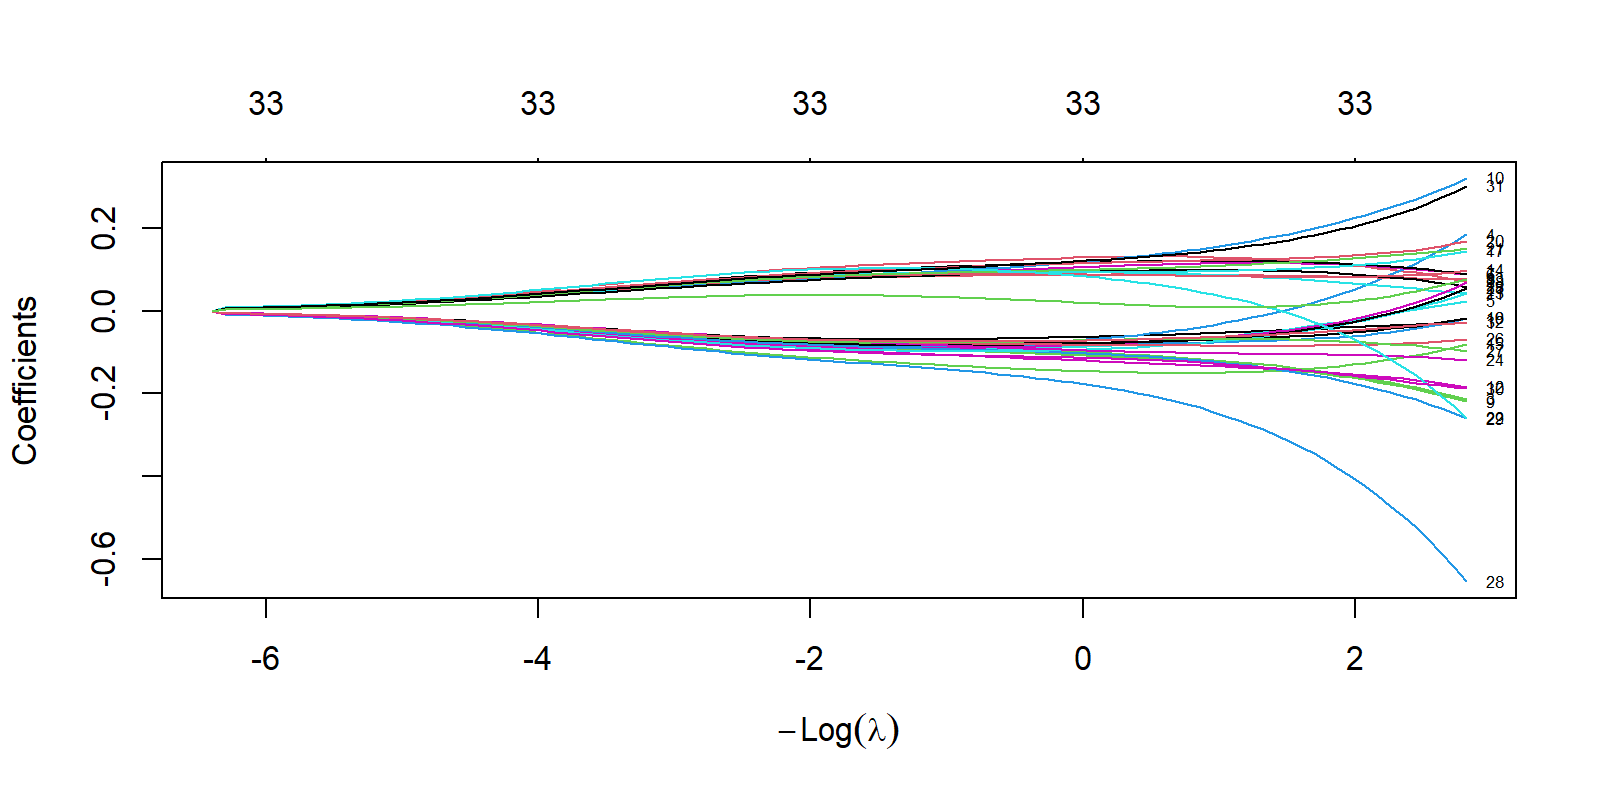

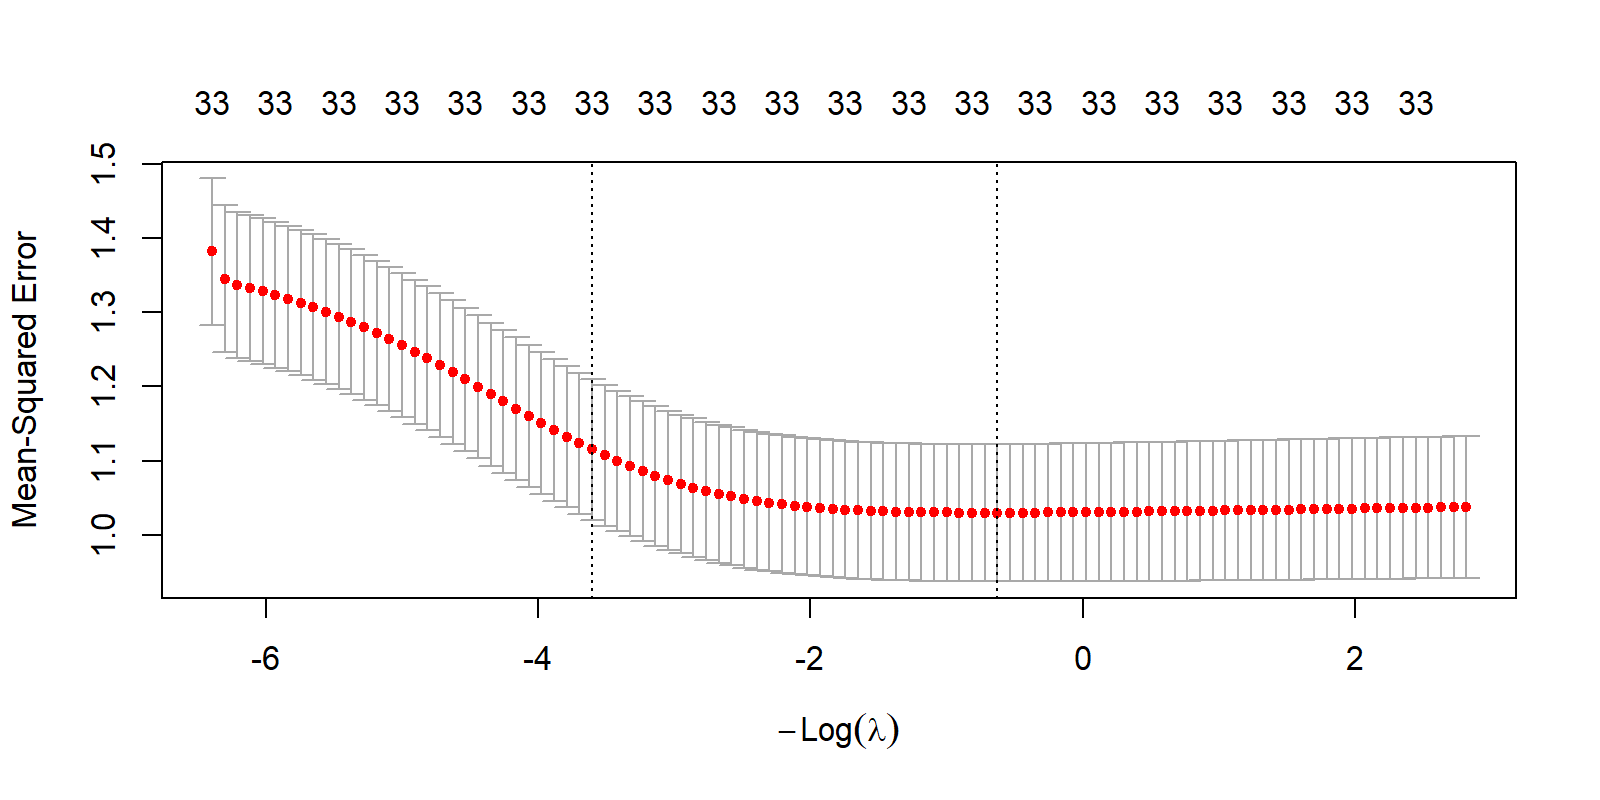

In [ ]:
%%R -i data -w 8 -h 4 --units in -r 200

library(glmnet)
X = as.matrix(data[,1:33])
y = as.matrix(data[,34])
p.fac = rep(1,34)
p.fac[34] = 0  # No penalty on covariate.

fit <- glmnet(X, y, alpha=0, penalty_factor = p.fac)
plot(fit, label=TRUE)

# Using glmnet function to build the ridge regression in r
ridge_cv <- cv.glmnet(X, y, alpha=0, penalty_factor = p.fac)
plot(ridge_cv)

best_lambda <- ridge_cv$lambda.min
print(best_lambda)

# Fit using best lambda.
m <- glmnet(X, y, alpha=0, penalty_factor = p.fac, lambda  = best_lambda)
coef(m)

[1] 3.162278
34 x 1 sparse Matrix of class "dgCMatrix"
                     s0
(Intercept)  1.45207678
X1          -0.08401881
X2           0.12061197
X3          -0.08576181
X4          -0.10157741
X5          -0.11655860
X6           0.08617245
X7           0.10530225
X8           0.09002295
X9          -0.09379977
X10          0.08254998
X11          0.09746615
X12         -0.10300468
X13          0.07872277
X14          0.10017503
X15         -0.12374969
X16         -0.08891220
X17          0.09784530
X18         -0.09277129
X19         -0.08614463
X20          0.10120333
X21          0.08691490
X22         -0.08839693
X23         -0.10608365
X24         -0.07706328
X25         -0.07408385
X26         -0.07317587
X27         -0.08418012
X28         -0.11893888
X29          0.11108437
X30         -0.10249594
X31          0.09712172
X32         -0.08281138
Z1           0.03575306


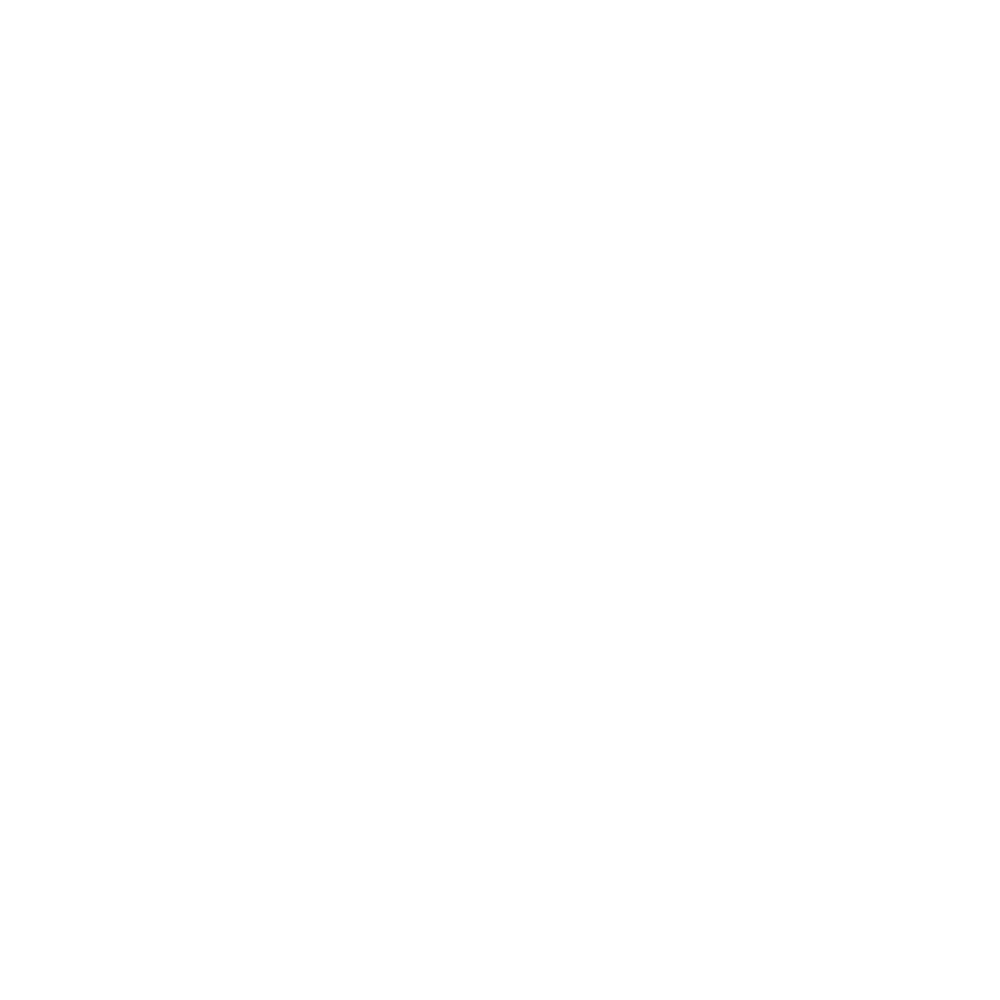

In [ ]:
# Compute predictions on validation set
device = 'cpu'

X, Z, y, v1, v2, v3, fx, fz, fr = experiments.traffic_light.dataset.simulate_traffic_light_data(n=800, seed=1234)
N = X.shape[0]
test_data = CovarDataset(X, Z, y)
test_loader = DataLoader(test_data, batch_size= N // 30, shuffle=False)

val_losses = []

for batch in test_loader:
    X_val, Z_val, y_val = batch["X"].to(device), batch["Z"].to(device), batch["y"].to(device)
    # Forward pass (linear model: yhat = fx*X + fz*Z + intercept)
    yhat = model(X_val).squeeze().detach().cpu()
    loss = ((y_val - yhat)**2).mean()
    val_losses.append(loss.item())

mean_val_loss = sum(val_losses) / len(val_losses)
print(mean_val_loss)

1.5259086393540906


In [ ]:
print(mean_val_loss)  # 1.57676213234663 (lam = 1)

1.578254222869873


In [ ]:
# Suppose val_loader yields batches: (X_val, Z_val, y_val)
# Candidate lambda values
lambda_grid = torch.logspace(-5, 5, 20)  # 20 values from 1e-5 to 1e2

best_lam = None
best_loss = float('inf')

for lam in lambda_grid:
    # Fit ridge on training data (replace X_train, Z_train, y_train with your tensors)
    posthoc_model._linear_fit_from_loader(train_loader, lam=lam.item())

    # Compute predictions on validation set
    val_losses = []
    for batch in val_loader:
        X_val, Z_val, y_val = batch["X"].to(device), batch["Z"].to(device), batch["y"].to(device)
        # Forward pass (linear model: yhat = fx*X + fz*Z + intercept)
        yhat = posthoc_model(X, Z).squeeze().detach().cpu()
        loss = ((y_val - yhat)**2).mean()
        val_losses.append(loss.item())

    mean_val_loss = sum(val_losses) / len(val_losses)

    print(f"Lambda: {lam.item():.5f}, validation MSE: {mean_val_loss:.5f}")

    if mean_val_loss < best_loss:
        best_loss = mean_val_loss
        best_lam = lam.item()

print(f"Optimal lambda: {best_lam:.5f}, validation MSE: {best_loss:.5f}")

Lambda: 0.00001, validation MSE: 1.66398
Lambda: 0.00003, validation MSE: 1.66095
Lambda: 0.00011, validation MSE: 1.65761
Lambda: 0.00038, validation MSE: 1.65459
Lambda: 0.00127, validation MSE: 1.65248
Lambda: 0.00428, validation MSE: 1.65123
Lambda: 0.01438, validation MSE: 1.65033
Lambda: 0.04833, validation MSE: 1.64893
Lambda: 0.16238, validation MSE: 1.64599
Lambda: 0.54556, validation MSE: 1.64122
Lambda: 1.83298, validation MSE: 1.63674
Lambda: 6.15848, validation MSE: 1.63257
Lambda: 20.69138, validation MSE: 1.62416
Lambda: 69.51928, validation MSE: 1.60285
Lambda: 233.57214, validation MSE: 1.56462
Lambda: 784.75995, validation MSE: 1.53248
Lambda: 2636.65088, validation MSE: 1.52221
Lambda: 8858.66797, validation MSE: 1.52080
Lambda: 29763.51367, validation MSE: 1.52072
Lambda: 100000.00000, validation MSE: 1.52074
Optimal lambda: 29763.51367, validation MSE: 1.52072
